# AlphaQuant: Deep Learning for Market Forecasting and Portfolio Optimization

This notebook demonstrates the end-to-end model development process, encompassing data preprocessing, multi-horizon LSTM forecasting, trading signal classification, and risk-adjusted portfolio optimization.

In [ ]:
# Your code goes here

# 1. Multi-Horizon Time-Series Forecasting (Nasdaq)

## 1.1 Data Preprocessing & Baseline LSTM

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/100
96/96 - 9s - 89ms/step - loss: 0.0135 - val_loss: 0.0012
Epoch 2/100
96/96 - 2s - 23ms/step - loss: 6.7770e-04 - val_loss: 8.7981e-04
Epoch 3/100
96/96 - 2s - 23ms/step - loss: 6.2604e-04 - val_loss: 7.0220e-04
Epoch 4/100
96/96 - 2s - 23ms/step - loss: 5.8302e-04 - val_loss: 9.6256e-04
Epoch 5/100
96/96 - 5s - 51ms/step - loss: 5.2903e-04 - val_loss: 6.0211e-04
Epoch 6/100
96/96 - 4s - 47ms/step - loss: 4.7721e-04 - val_loss: 5.9178e-04
Epoch 7/100
96/96 - 5s - 49ms/step - loss: 4.6448e-04 - val_loss: 4.6885e-04
Epoch 8/100
96/96 - 5s - 57ms/step - loss: 4.0836e-04 - val_loss: 5.9464e-04
Epoch 9/100
96/96 - 5s - 57ms/step - loss: 3.6279e-04 - val_loss: 5.6460e-04
Epoch 10/100
96/96 - 4s - 47ms/step - loss: 3.3483e-04 - val_loss: 5.7910e-04
Epoch 11/100
96/96 - 6s - 58ms/step - loss: 3.1788e-04 - val_loss: 2.8138e-04
Epoch 12/100
96/96 - 3s - 35ms

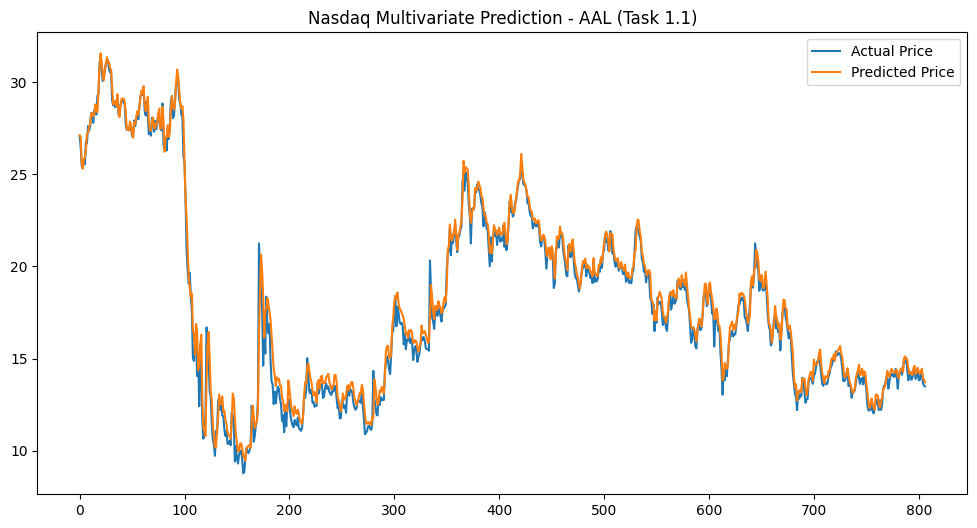

In [23]:
# 1. Create multivariate dataset
def create_dataset(dataset, time_step=1, target_idx=2):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

# 2. Load data
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/AAL.csv'
df = pd.read_csv(file_path)

# Select features
features = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
dataset = df[features].values
dataset = dataset.astype('float32')

# 3. Split Train/Test before Scaling
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# 4. Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Separate scaler for the target column (Open price)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, 2].reshape(-1, 1))

time_step = 60

# 5. Create Train/Test datasets
target_col_idx = 2
trainX, trainY = create_dataset(train, time_step, target_col_idx)
testX, testY = create_dataset(test, time_step, target_col_idx)

# 6. Build LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(time_step, 6)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# 7. Train model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model.fit(trainX, trainY, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)

# 8. Predict and inverse scale
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
y_pred_norm = model.predict(testX)

# Calculate MSE on normalized test set
print("MSE on the test set: ", mean_squared_error(y_pred_norm, testY))

trainPredict = target_scaler.inverse_transform(trainPredict)
testPredict = target_scaler.inverse_transform(testPredict)

# Calculate metrics on actual prices
testY_real = target_scaler.inverse_transform(testY.reshape(-1, 1))
mae  = mean_absolute_error(testY_real, testPredict)
rmse = np.sqrt(mean_squared_error(testY_real, testPredict))
mape = np.mean(np.abs((testY_real - testPredict) / testY_real)) * 100

print(f"MAE  on the test set: {mae:.4f} USD")
print(f"RMSE on the test set: {rmse:.4f} USD")
print(f"MAPE on the test set: {mape:.2f}%")

# 9. Plot predictions vs actuals
testY_plot = target_scaler.inverse_transform(testY.reshape(-1, 1))

plt.figure(figsize=(12,6))
plt.plot(testY_plot, label='Actual Price')
plt.plot(testPredict, label='Predicted Price')
plt.title('Nasdaq Multivariate Prediction - AAL (Task 1.1)')
plt.legend()
plt.show()

## 1.2 K-Days Ahead Prediction

Epoch 1/50
96/96 - 8s - 80ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 2/50
96/96 - 2s - 22ms/step - loss: 9.0053e-04 - val_loss: 0.0014
Epoch 3/50
96/96 - 3s - 27ms/step - loss: 7.9602e-04 - val_loss: 7.6869e-04
Epoch 4/50
96/96 - 2s - 26ms/step - loss: 7.4980e-04 - val_loss: 0.0015
Epoch 5/50
96/96 - 4s - 39ms/step - loss: 6.7806e-04 - val_loss: 6.8958e-04
Epoch 6/50
96/96 - 4s - 37ms/step - loss: 6.5982e-04 - val_loss: 8.9212e-04
Epoch 7/50
96/96 - 3s - 29ms/step - loss: 6.4772e-04 - val_loss: 6.0528e-04
Epoch 8/50
96/96 - 2s - 24ms/step - loss: 6.0552e-04 - val_loss: 8.3721e-04
Epoch 9/50
96/96 - 3s - 28ms/step - loss: 6.0919e-04 - val_loss: 0.0017
Epoch 10/50
96/96 - 4s - 38ms/step - loss: 5.9725e-04 - val_loss: 5.8057e-04
Epoch 11/50
96/96 - 2s - 23ms/step - loss: 5.5424e-04 - val_loss: 5.6578e-04
Epoch 12/50
96/96 - 2s - 22ms/step - loss: 5.7891e-04 - val_loss: 6.7401e-04
Epoch 13/50
96/96 - 3s - 28ms/step - loss: 5.4934e-04 - val_loss: 7.4813e-04
Epoch 14/50
96/96 - 6s - 63m

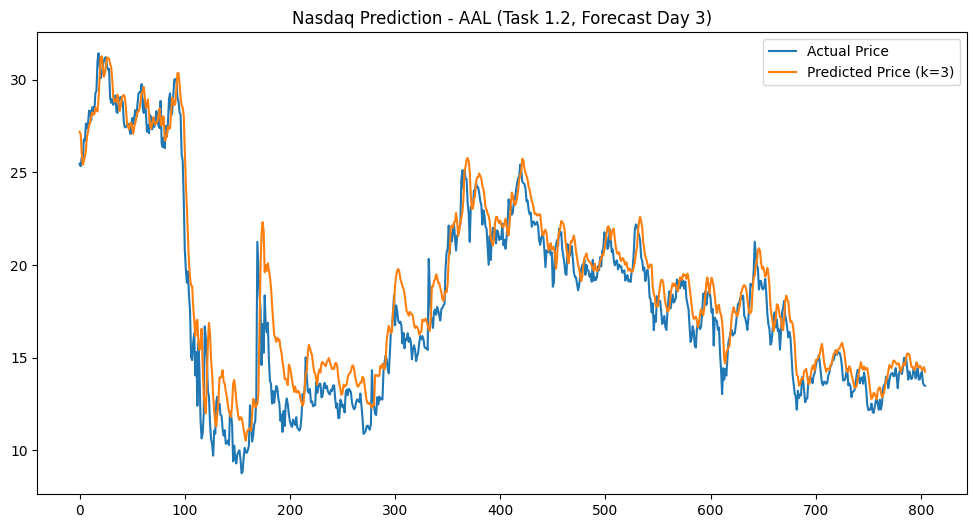

In [26]:
# Create dataset for k-days ahead prediction
def create_dataset_multivariate(dataset, time_step=1, target_idx=2, k=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

# 1. Configure k-days ahead (Task 1.2)
k_days = 3

# 2. Create datasets for day k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)

# 3. Build model
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
early_stop_k3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=50, batch_size=32,
            validation_split=0.1, callbacks=[early_stop_k3], verbose=2)

# 5. Predict and evaluate on normalized test set
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Inverse scale and plot
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

# Calculate metrics
mae_k  = mean_absolute_error(y_test_real_k, y_pred_real_k)
rmse_k = np.sqrt(mean_squared_error(y_test_real_k, y_pred_real_k))
mape_k = np.mean(np.abs((y_test_real_k - y_pred_real_k) / y_test_real_k)) * 100

print(f"MAE  on the test set (k={k_days}): {mae_k:.4f} USD")
print(f"RMSE on the test set (k={k_days}): {rmse_k:.4f} USD")
print(f"MAPE on the test set (k={k_days}): {mape_k:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - AAL (Task 1.2, Forecast Day {k_days})')
plt.legend()
plt.show()

Epoch 1/50
96/96 - 4s - 44ms/step - loss: 0.0095 - val_loss: 0.0021
Epoch 2/50
96/96 - 2s - 22ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 3/50
96/96 - 4s - 43ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 4/50
96/96 - 2s - 24ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 5/50
96/96 - 2s - 25ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 6/50
96/96 - 2s - 22ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 7/50
96/96 - 2s - 22ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 8/50
96/96 - 3s - 29ms/step - loss: 0.0014 - val_loss: 0.0020
Epoch 9/50
96/96 - 4s - 37ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 10/50
96/96 - 3s - 28ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 11/50
96/96 - 2s - 22ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 12/50
96/96 - 3s - 29ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 13/50
96/96 - 7s - 78ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 14/50
96/96 - 4s - 46ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 15/50
96/96 - 3s - 33ms/step - loss: 

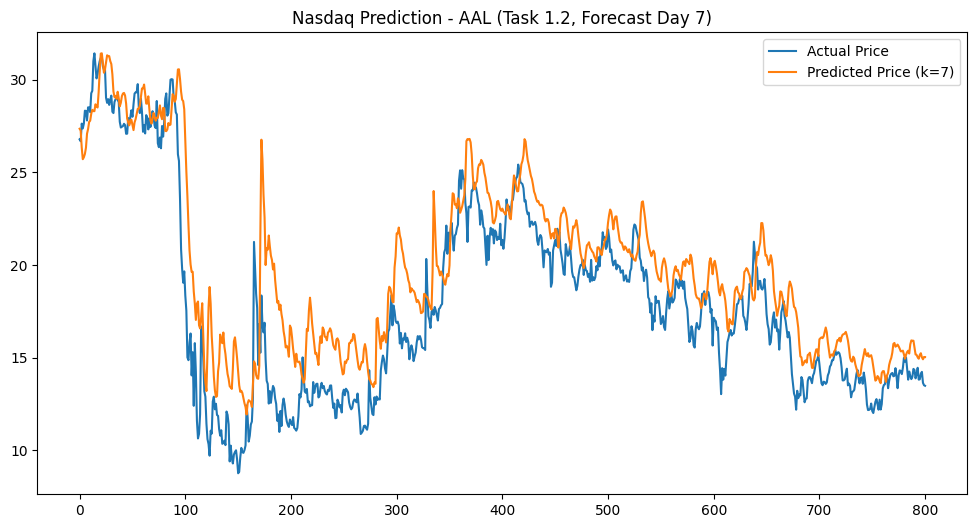

In [27]:
# 1. Configure k-days ahead (Task 1.2)
k_days = 7

# 2. Create datasets for day k
trainX_k, trainY_k = create_dataset_multivariate(train, time_step, target_idx=2, k=k_days)
testX_k, testY_k = create_dataset_multivariate(test, time_step, target_idx=2, k=k_days)

# 3. Build model
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 6)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
early_stop_k7 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=50, batch_size=32,
            validation_split=0.1, callbacks=[early_stop_k7], verbose=2)

# 5. Predict and evaluate on normalized test set
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days}): ", mean_squared_error(y_pred_norm_k, testY_k))

# 6. Inverse scale and plot
y_test_real_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_real_k = target_scaler.inverse_transform(y_pred_norm_k)

# Calculate metrics
mae_k  = mean_absolute_error(y_test_real_k, y_pred_real_k)
rmse_k = np.sqrt(mean_squared_error(y_test_real_k, y_pred_real_k))
mape_k = np.mean(np.abs((y_test_real_k - y_pred_real_k) / y_test_real_k)) * 100

print(f"MAE  on the test set (k={k_days}): {mae_k:.4f} USD")
print(f"RMSE on the test set (k={k_days}): {rmse_k:.4f} USD")
print(f"MAPE on the test set (k={k_days}): {mape_k:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(y_test_real_k, label='Actual Price')
plt.plot(y_pred_real_k, label=f'Predicted Price (k={k_days})')
plt.title(f'Nasdaq Prediction - AAL (Task 1.2, Forecast Day {k_days})')
plt.legend()
plt.show()

## 1.3 Sequence-to-Sequence Prediction

Epoch 1/50
96/96 - 5s - 55ms/step - loss: 0.0161 - val_loss: 0.0012
Epoch 2/50
96/96 - 3s - 36ms/step - loss: 8.5749e-04 - val_loss: 9.7000e-04
Epoch 3/50
96/96 - 2s - 22ms/step - loss: 7.8457e-04 - val_loss: 0.0010
Epoch 4/50
96/96 - 3s - 27ms/step - loss: 7.3868e-04 - val_loss: 9.9241e-04
Epoch 5/50
96/96 - 6s - 60ms/step - loss: 7.0807e-04 - val_loss: 7.8538e-04
Epoch 6/50
96/96 - 3s - 36ms/step - loss: 6.6850e-04 - val_loss: 7.2000e-04
Epoch 7/50
96/96 - 2s - 23ms/step - loss: 6.1802e-04 - val_loss: 6.5692e-04
Epoch 8/50
96/96 - 2s - 26ms/step - loss: 5.9717e-04 - val_loss: 9.2832e-04
Epoch 9/50
96/96 - 2s - 22ms/step - loss: 5.5931e-04 - val_loss: 5.8667e-04
Epoch 10/50
96/96 - 2s - 22ms/step - loss: 5.3768e-04 - val_loss: 7.6322e-04
Epoch 11/50
96/96 - 3s - 33ms/step - loss: 5.2293e-04 - val_loss: 6.8242e-04
Epoch 12/50
96/96 - 3s - 34ms/step - loss: 5.0111e-04 - val_loss: 5.2397e-04
Epoch 13/50
96/96 - 2s - 22ms/step - loss: 4.7795e-04 - val_loss: 5.2378e-04
Epoch 14/50
96/96 - 

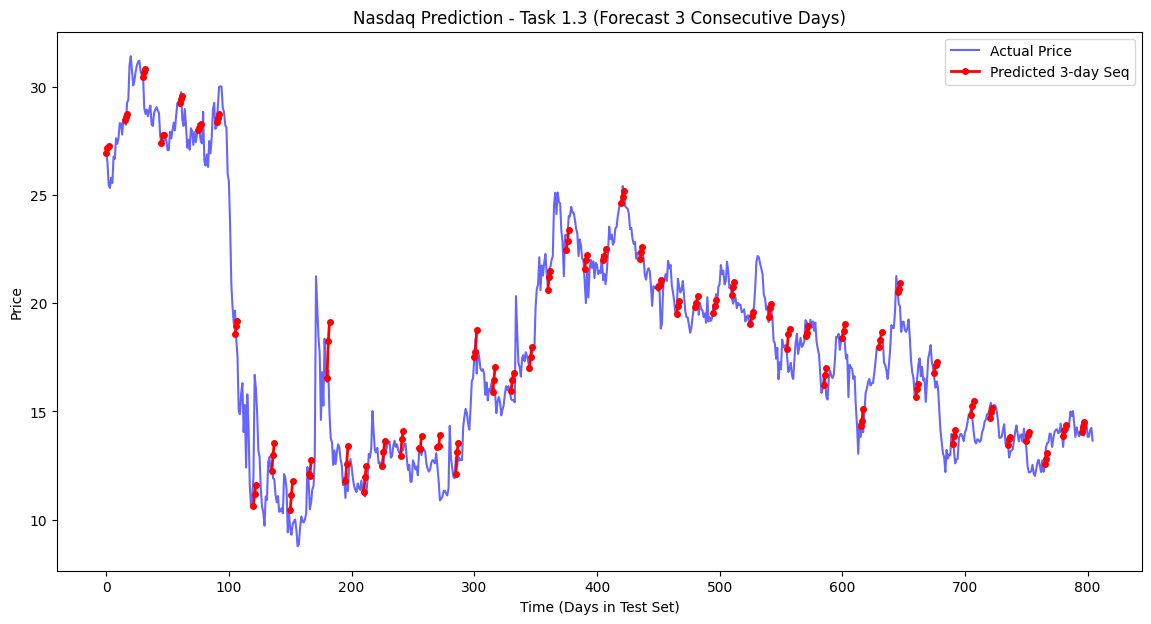

In [28]:
# Create dataset for sequence prediction
def create_dataset_sequence(dataset, time_step=60, target_idx=2, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])
    return np.array(dataX), np.array(dataY)

# 1. Configure sequence length (Task 1.3)
k_seq = 3

# 2. Create sequence datasets
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)

# 3. Build sequence model
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))
# Dense units must equal k_seq
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
early_stop_seq3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq.fit(trainX_seq, trainY_seq, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[early_stop_seq3], verbose=2)

# 5. Predict and evaluate normalized MSE
y_pred_norm_seq = model_seq.predict(testX_seq)
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Flatten, inverse scale, and reshape
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# Calculate metrics
mae_seq  = mean_absolute_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten())
rmse_seq = np.sqrt(mean_squared_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten()))
mape_seq = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100

print(f"MAE  on the test set (k={k_seq}): {mae_seq:.4f} USD")
print(f"RMSE on the test set (k={k_seq}): {rmse_seq:.4f} USD")
print(f"MAPE on the test set (k={k_seq}): {mape_seq:.2f}%")

# 7. Plot sequence predictions
plt.figure(figsize=(14, 7))

# Plot actual price
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Plot predicted sequences at intervals
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    x_axis = range(i, i + k_seq)
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - Task 1.3 (Forecast {k_seq} Consecutive Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

Epoch 1/50
96/96 - 6s - 62ms/step - loss: 0.0193 - val_loss: 0.0019
Epoch 2/50
96/96 - 4s - 38ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 3/50
96/96 - 4s - 39ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 4/50
96/96 - 2s - 26ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 5/50
96/96 - 4s - 40ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 6/50
96/96 - 2s - 24ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 7/50
96/96 - 2s - 23ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 8/50
96/96 - 3s - 29ms/step - loss: 9.6639e-04 - val_loss: 0.0012
Epoch 9/50
96/96 - 2s - 24ms/step - loss: 9.2101e-04 - val_loss: 0.0012
Epoch 10/50
96/96 - 5s - 52ms/step - loss: 9.0204e-04 - val_loss: 0.0011
Epoch 11/50
96/96 - 5s - 52ms/step - loss: 8.8887e-04 - val_loss: 0.0010
Epoch 12/50
96/96 - 4s - 45ms/step - loss: 9.0563e-04 - val_loss: 0.0014
Epoch 13/50
96/96 - 5s - 47ms/step - loss: 8.7047e-04 - val_loss: 9.5423e-04
Epoch 14/50
96/96 - 3s - 31ms/step - loss: 8.5319e-04 - val_loss: 0.0014
Epoch 15/50

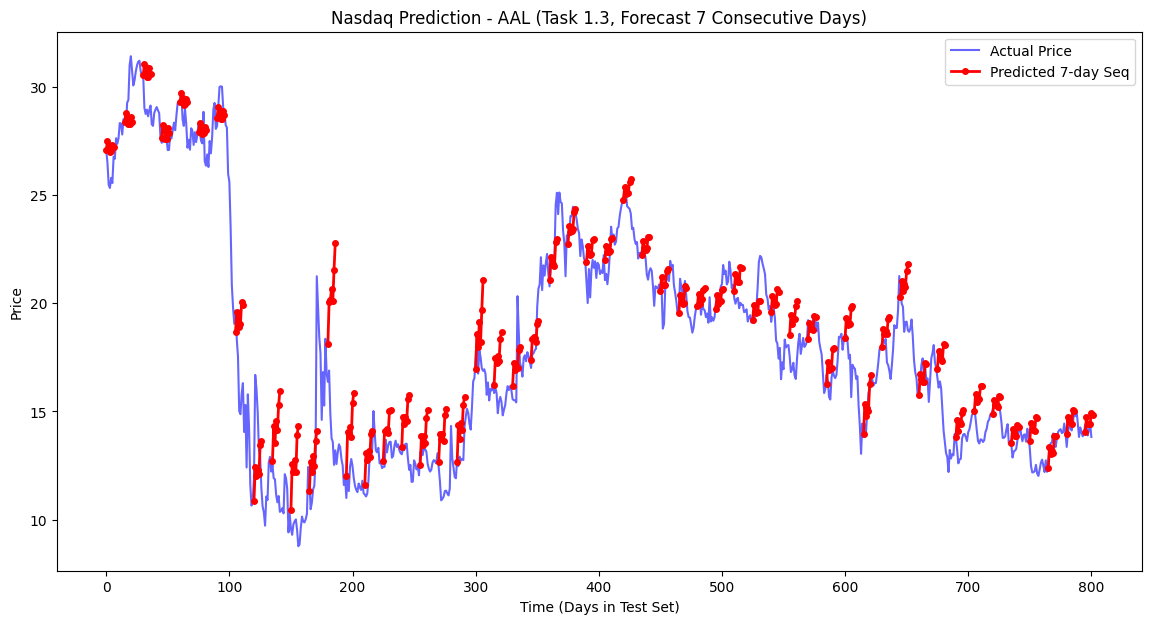

In [29]:
# 1. Configure sequence length (Task 1.3)
k_seq = 7

# 2. Create sequence datasets using previously defined function
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=2, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=2, k=k_seq)

# 3. Build sequence model
model_seq = Sequential()
model_seq.add(LSTM(50, input_shape=(time_step, 6)))
model_seq.add(Dense(k_seq))
model_seq.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
early_stop_seq7 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq.fit(trainX_seq, trainY_seq, epochs=50, batch_size=32,
              validation_split=0.1, callbacks=[early_stop_seq7], verbose=2)

# 5. Predict and evaluate normalized MSE
y_pred_norm_seq = model_seq.predict(testX_seq)
print(f"MSE on the test set (Normalized, Sequence k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Flatten, inverse scale, and reshape
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# Calculate metrics
mae_seq  = mean_absolute_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten())
rmse_seq = np.sqrt(mean_squared_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten()))
mape_seq = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100

print(f"MAE  on the test set (k={k_seq}): {mae_seq:.4f} USD")
print(f"RMSE on the test set (k={k_seq}): {rmse_seq:.4f} USD")
print(f"MAPE on the test set (k={k_seq}): {mape_seq:.2f}%")

# 7. Plot sequence predictions
plt.figure(figsize=(14, 7))

# Plot actual price
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price', alpha=0.6)

# Plot predicted sequences at intervals
interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    x_axis = range(i, i + k_seq)
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Nasdaq Prediction - AAL (Task 1.3, Forecast {k_seq} Consecutive Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Price')
plt.legend()
plt.show()

# 2. Multi-Horizon Time-Series Forecasting (SAM Stock)

## 2.1 Data Preprocessing & Baseline LSTM (SAM Stock)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/100
121/121 - 8s - 67ms/step - loss: 0.0020 - val_loss: 7.8058e-05
Epoch 2/100
121/121 - 3s - 29ms/step - loss: 2.8551e-04 - val_loss: 6.9984e-05
Epoch 3/100
121/121 - 5s - 41ms/step - loss: 2.3612e-04 - val_loss: 6.0380e-05
Epoch 4/100
121/121 - 3s - 22ms/step - loss: 2.2226e-04 - val_loss: 5.9252e-05
Epoch 5/100
121/121 - 5s - 38ms/step - loss: 1.8069e-04 - val_loss: 5.4269e-05
Epoch 6/100
121/121 - 3s - 24ms/step - loss: 1.7537e-04 - val_loss: 4.6833e-05
Epoch 7/100
121/121 - 3s - 24ms/step - loss: 1.5147e-04 - val_loss: 4.9315e-05
Epoch 8/100
121/121 - 3s - 21ms/step - loss: 1.4051e-04 - val_loss: 5.0044e-05
Epoch 9/100
121/121 - 3s - 26ms/step - loss: 1.4310e-04 - val_loss: 1.1640e-04
Epoch 10/100
121/121 - 4s - 35ms/step - loss: 1.3108e-04 - val_loss: 1.2567e-04
Epoch 11/100
121/121 - 3s - 26ms/step - loss: 1.2786e-04 - val_loss: 7.3487e-05
Epoc

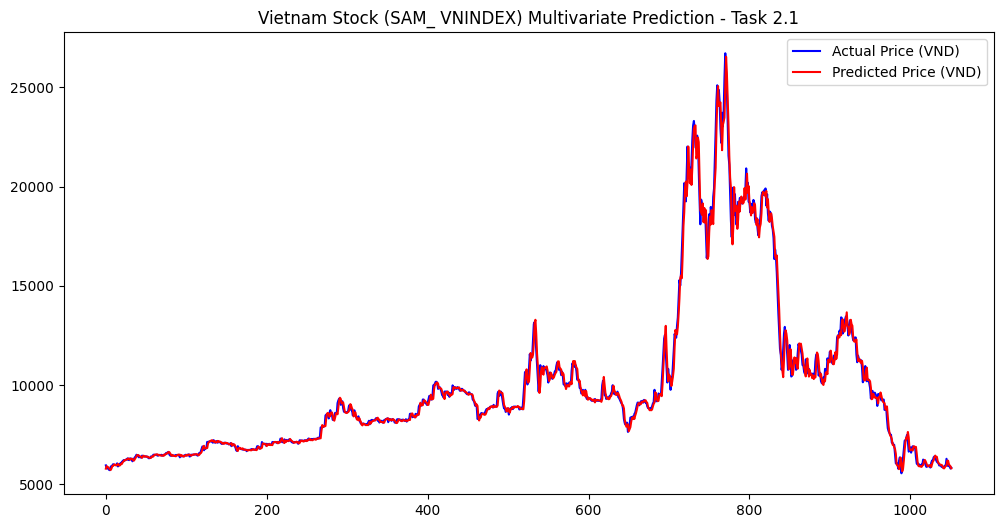

In [31]:
# Create multivariate dataset
def create_dataset(dataset, time_step=1, target_idx=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step, target_idx])
    return np.array(dataX), np.array(dataY)

# Load data
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data-vn-20230228/stock-historical-data/SAM-VNINDEX-History.csv'
df = pd.read_csv(file_path)

# Sort dates chronologically
if 'TradingDate' in df.columns:
    df['TradingDate'] = pd.to_datetime(df['TradingDate'])
    df = df.sort_values('TradingDate').reset_index(drop=True)

# Select features
features_vn = ['Low', 'High', 'Open', 'Close', 'Volume']
dataset = df[features_vn].values
dataset = dataset.astype('float32')

# Train/Test split
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
train = scaler.fit_transform(train)
test = scaler.transform(test)

# Target scaler for 'Close' (index 3)
target_idx = 3
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(dataset[0:train_size, target_idx].reshape(-1, 1))

# Create datasets
time_step = 30
trainX, trainY = create_dataset(train, time_step, target_idx)
testX, testY = create_dataset(test, time_step, target_idx)

# Build model
model = Sequential()
model.add(LSTM(50, input_shape=(time_step, 5)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model.fit(trainX, trainY, epochs=100, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=2)

# Predict
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
y_pred_norm = model.predict(testX)

# Evaluate normalized MSE
print("MSE on the test set: ", mean_squared_error(y_pred_norm, testY))

# Inverse transform
trainPredict = target_scaler.inverse_transform(trainPredict)
testPredict = target_scaler.inverse_transform(testPredict)
testY_real = target_scaler.inverse_transform(testY.reshape(-1, 1))

# Calculate metrics
mae  = mean_absolute_error(testY_real, testPredict)
rmse = np.sqrt(mean_squared_error(testY_real, testPredict))
mape = np.mean(np.abs((testY_real - testPredict) / testY_real)) * 100

print(f"MAE  on the test set: {mae:.4f} VND")
print(f"RMSE on the test set: {rmse:.4f} VND")
print(f"MAPE on the test set: {mape:.2f}%")

# Plot
plt.figure(figsize=(12,6))
plt.plot(testY_real, label='Actual Price (VND)', color='blue')
plt.plot(testPredict, label='Predicted Price (VND)', color='red')
plt.title('Vietnam Stock (SAM_ VNINDEX) Multivariate Prediction - Task 2.1')
plt.legend()
plt.show()

## 2.2 K-Days Ahead Prediction (SAM Stock)


--- Training 3-day ahead prediction (SAM) ---
Epoch 1/100
121/121 - 7s - 54ms/step - loss: 8.3898e-04 - val_loss: 9.6503e-05
Epoch 2/100
121/121 - 2s - 19ms/step - loss: 4.0340e-04 - val_loss: 1.1226e-04
Epoch 3/100
121/121 - 2s - 14ms/step - loss: 3.5738e-04 - val_loss: 9.3501e-05
Epoch 4/100
121/121 - 3s - 22ms/step - loss: 3.6867e-04 - val_loss: 8.7067e-05
Epoch 5/100
121/121 - 2s - 13ms/step - loss: 3.4570e-04 - val_loss: 1.4031e-04
Epoch 6/100
121/121 - 4s - 30ms/step - loss: 3.4485e-04 - val_loss: 1.3481e-04
Epoch 7/100
121/121 - 2s - 19ms/step - loss: 3.0910e-04 - val_loss: 1.0056e-04
Epoch 8/100
121/121 - 2s - 13ms/step - loss: 2.8345e-04 - val_loss: 9.3717e-05
Epoch 9/100
121/121 - 2s - 13ms/step - loss: 2.6694e-04 - val_loss: 9.3751e-05
Epoch 10/100
121/121 - 2s - 14ms/step - loss: 2.8205e-04 - val_loss: 1.0391e-04
Epoch 11/100
121/121 - 2s - 20ms/step - loss: 2.7894e-04 - val_loss: 8.4189e-05
Epoch 12/100
121/121 - 3s - 24ms/step - loss: 2.6375e-04 - val_loss: 8.5922e-05
Ep

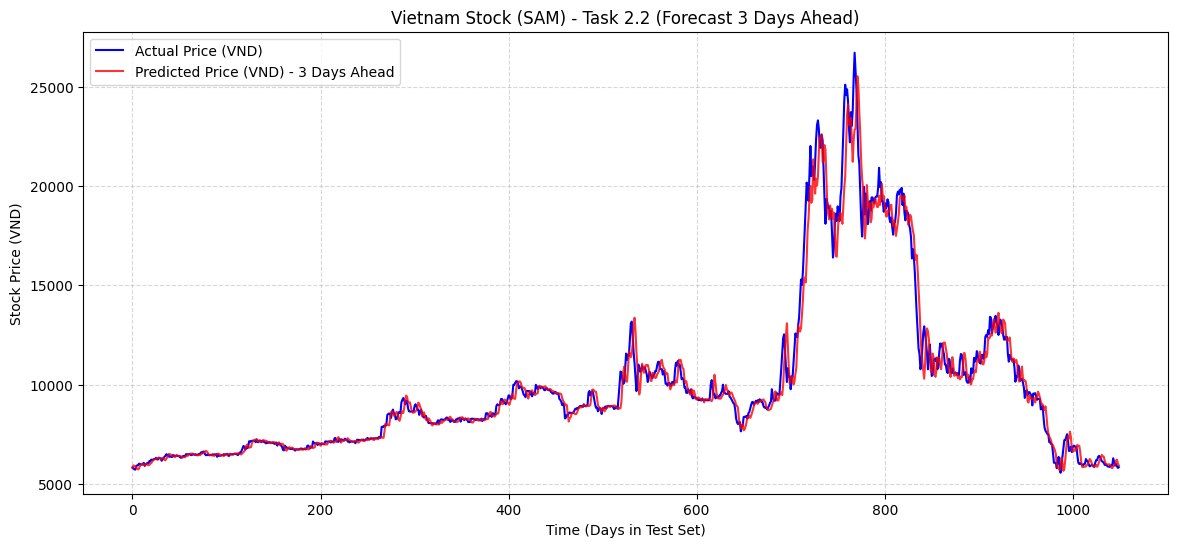

In [32]:
# Create dataset for kth day prediction
def create_dataset_kth_day(dataset, time_step=30, target_idx=3, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step + k - 1, target_idx])
    return np.array(dataX), np.array(dataY)

# 1. Configure k days ahead
k_days_ahead = 3

# 2. Create datasets
trainX_k, trainY_k = create_dataset_kth_day(train, time_step, target_idx, k=k_days_ahead)
testX_k, testY_k = create_dataset_kth_day(test, time_step, target_idx, k=k_days_ahead)

# 3. Build model
model_k = Sequential()
model_k.add(LSTM(50, input_shape=(time_step, 5)))
model_k.add(Dense(1))
model_k.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
print(f"\n--- Training {k_days_ahead}-day ahead prediction (SAM) ---")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_k.fit(trainX_k, trainY_k, epochs=100, batch_size=32,
            validation_split=0.1, callbacks=[early_stop], verbose=2)

# 5. Predict and evaluate normalized MSE
y_pred_norm_k = model_k.predict(testX_k)
print(f"MSE on the test set (Normalized, k={k_days_ahead}): ", mean_squared_error(testY_k, y_pred_norm_k))

# 6. Inverse transform
y_test_rescaled_k = target_scaler.inverse_transform(testY_k.reshape(-1, 1))
y_pred_rescaled_k = target_scaler.inverse_transform(y_pred_norm_k)

# 7. Calculate metrics
mae  = mean_absolute_error(y_test_rescaled_k, y_pred_rescaled_k)
rmse = np.sqrt(mean_squared_error(y_test_rescaled_k, y_pred_rescaled_k))
mape = np.mean(np.abs((y_test_rescaled_k - y_pred_rescaled_k) / y_test_rescaled_k)) * 100

print(f"MAE  on the test set: {mae:.4f} VND")
print(f"RMSE on the test set: {rmse:.4f} VND")
print(f"MAPE on the test set: {mape:.2f}%")

# 8. Plot results
plt.figure(figsize=(14,6))
plt.plot(y_test_rescaled_k, label='Actual Price (VND)', color='blue', linewidth=1.5)
plt.plot(y_pred_rescaled_k, label=f'Predicted Price (VND) - {k_days_ahead} Days Ahead', color='red', linewidth=1.5, alpha=0.8)
plt.title(f'Vietnam Stock (SAM) - Task 2.2 (Forecast {k_days_ahead} Days Ahead)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VND)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 2.3 Sequence-to-Sequence Prediction (SAM Stock)


--- Training 3-day sequence prediction (SAM) ---
Epoch 1/100
121/121 - 3s - 29ms/step - loss: 0.0027 - val_loss: 9.3586e-05
Epoch 2/100
121/121 - 2s - 20ms/step - loss: 4.8056e-04 - val_loss: 1.1517e-04
Epoch 3/100
121/121 - 2s - 20ms/step - loss: 3.6637e-04 - val_loss: 8.4180e-05
Epoch 4/100
121/121 - 3s - 27ms/step - loss: 3.2588e-04 - val_loss: 8.0523e-05
Epoch 5/100
121/121 - 2s - 13ms/step - loss: 3.0417e-04 - val_loss: 1.0790e-04
Epoch 6/100
121/121 - 2s - 13ms/step - loss: 2.9166e-04 - val_loss: 8.2065e-05
Epoch 7/100
121/121 - 2s - 13ms/step - loss: 2.5396e-04 - val_loss: 8.8623e-05
Epoch 8/100
121/121 - 2s - 13ms/step - loss: 2.6939e-04 - val_loss: 9.4521e-05
Epoch 9/100
121/121 - 3s - 21ms/step - loss: 2.4596e-04 - val_loss: 7.5315e-05
Epoch 10/100
121/121 - 4s - 30ms/step - loss: 2.3595e-04 - val_loss: 1.5598e-04
Epoch 11/100
121/121 - 3s - 28ms/step - loss: 2.2371e-04 - val_loss: 7.5685e-05
Epoch 12/100
121/121 - 3s - 24ms/step - loss: 2.3281e-04 - val_loss: 9.4838e-05
Epo

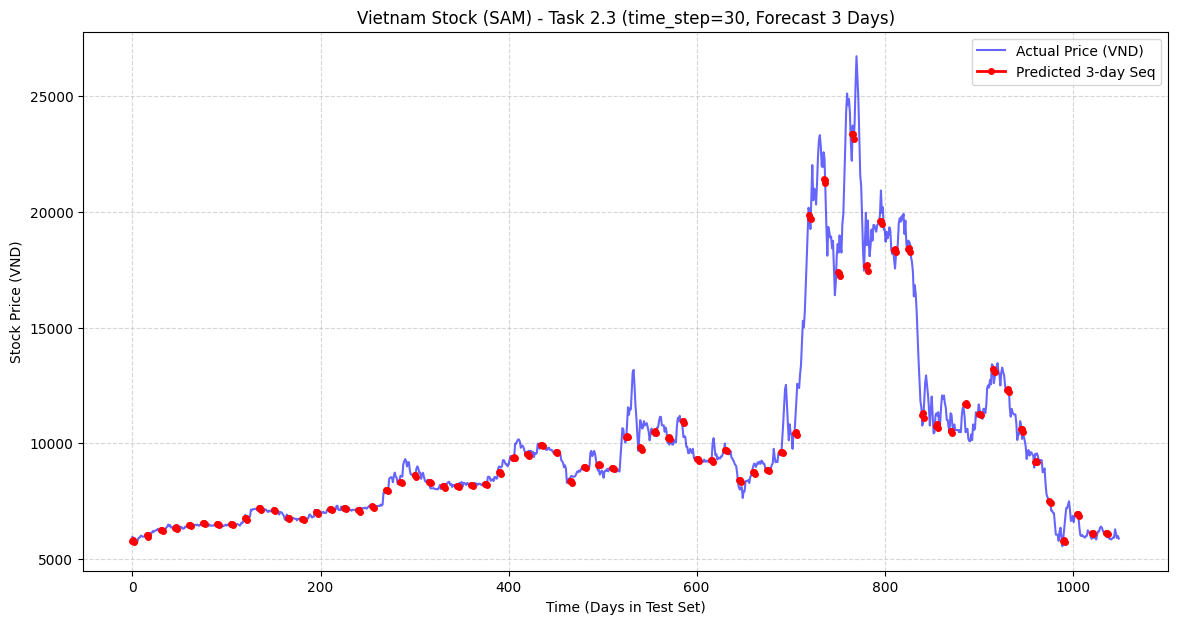

In [33]:
# Create sequence dataset
def create_dataset_sequence(dataset, time_step=30, target_idx=3, k=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - k + 1):
        a = dataset[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(dataset[i + time_step : i + time_step + k, target_idx])
    return np.array(dataX), np.array(dataY)

# 1. Configure parameters
time_step = 30
k_seq = 3

# 2. Create datasets
trainX_seq, trainY_seq = create_dataset_sequence(train, time_step, target_idx=3, k=k_seq)
testX_seq, testY_seq = create_dataset_sequence(test, time_step, target_idx=3, k=k_seq)

# 3. Build model
model_seq_vn = Sequential()
model_seq_vn.add(LSTM(50, input_shape=(time_step, 5)))
model_seq_vn.add(Dense(k_seq))
model_seq_vn.compile(loss='mean_squared_error', optimizer='adam')

# 4. Train model
print(f"\n--- Training {k_seq}-day sequence prediction (SAM) ---")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_seq_vn.fit(trainX_seq, trainY_seq, epochs=100, batch_size=32,
                 validation_split=0.1, callbacks=[early_stop], verbose=2)

# 5. Predict and evaluate
y_pred_norm_seq = model_seq_vn.predict(testX_seq)
print(f"MSE on the test set (Normalized, time_step={time_step}, k={k_seq}): ", mean_squared_error(testY_seq, y_pred_norm_seq))

# 6. Inverse transform
y_test_real_seq = target_scaler.inverse_transform(testY_seq.reshape(-1, 1)).reshape(-1, k_seq)
y_pred_real_seq = target_scaler.inverse_transform(y_pred_norm_seq.reshape(-1, 1)).reshape(-1, k_seq)

# Calculate metrics (flattened for sequence arrays)
mae = mean_absolute_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten())
rmse = np.sqrt(mean_squared_error(y_test_real_seq.flatten(), y_pred_real_seq.flatten()))
mape = np.mean(np.abs((y_test_real_seq - y_pred_real_seq) / y_test_real_seq)) * 100

print(f"MAE  on the test set: {mae:.4f} VND")
print(f"RMSE on the test set: {rmse:.4f} VND")
print(f"MAPE on the test set: {mape:.2f}%")

# 7. Plot results
plt.figure(figsize=(14, 7))
plt.plot(y_test_real_seq[:, 0], color='blue', label='Actual Price (VND)', alpha=0.6, linewidth=1.5)

interval = 15
for i in range(0, len(y_pred_real_seq), interval):
    x_axis = range(i, i + k_seq)
    if i == 0:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2, label=f'Predicted {k_seq}-day Seq')
    else:
        plt.plot(x_axis, y_pred_real_seq[i], color='red', marker='o', markersize=4, linewidth=2)

plt.title(f'Vietnam Stock (SAM) - Task 2.3 (time_step={time_step}, Forecast {k_seq} Days)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('Stock Price (VND)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Algorithmic Trading Signal Classification

## 3.1 Buy Signal Classification

In [35]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# 1. Configure paths
base_path = '/content/drive/MyDrive/data-vn-20230228'
history_path = os.path.join(base_path, 'stock-historical-data')
finance_path = os.path.join(base_path, 'financial-ratio')
dividend_path = os.path.join(base_path, 'dividend-history')

target_history_file = 'SAM-VNINDEX-History.csv'
base_name = target_history_file.replace('-History.csv', '')

print(f"--- Processing data for: {base_name.split('-')[0]} ---")

# Step 1: Price Data
df_price = pd.read_csv(os.path.join(history_path, target_history_file))

if 'TradingDate' in df_price.columns:
    df_price['TradingDate'] = pd.to_datetime(df_price['TradingDate'])
    df_price = df_price.sort_values('TradingDate').reset_index(drop=True)

# Feature engineering
df_price['Log_Return'] = np.log(df_price['Close'] / df_price['Close'].shift(1))
df_price['Volatility_14'] = df_price['Log_Return'].rolling(window=14).std()
df_price['SMA_14'] = df_price['Close'].rolling(window=14).mean()
df_price['Dist_to_SMA'] = (df_price['Close'] - df_price['SMA_14']) / df_price['SMA_14']

delta = df_price['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_price['RSI_14'] = 100 - (100 / (1 + rs))

# Step 2: Financial Ratio
finance_file = f"{base_name}-Finance.csv"
finance_full_path = os.path.join(finance_path, finance_file)

if os.path.exists(finance_full_path):
    print(f"-> Found finance file: {finance_file}")
    df_fin = pd.read_csv(finance_full_path)

    def get_quarter_end(row):
        try:
            q, y = int(row['quarter']), int(row['year'])
            if q == 1: return pd.Timestamp(y, 3, 31)
            elif q == 2: return pd.Timestamp(y, 6, 30)
            elif q == 3: return pd.Timestamp(y, 9, 30)
            elif q == 4: return pd.Timestamp(y, 12, 31)
        except:
            return pd.NaT

    if 'quarter' in df_fin.columns and 'year' in df_fin.columns:
        df_fin['ReportDate'] = df_fin.apply(get_quarter_end, axis=1)

        cols_to_keep = ['ReportDate', 'priceToEarning', 'roe', 'roa']
        cols_to_keep = [c for c in cols_to_keep if c in df_fin.columns]
        df_fin = df_fin[cols_to_keep]

        df_price = pd.merge(df_price, df_fin, left_on='TradingDate', right_on='ReportDate', how='left')

        for col in cols_to_keep:
            if col != 'ReportDate':
                df_price[col] = df_price[col].fillna(method='ffill')

        df_price.drop(columns=['ReportDate'], inplace=True, errors='ignore')
else:
    print(f"-> Finance file not found: {finance_file}")

# Step 3: Dividend History
dividend_file = f"{base_name}-Dividend.csv"
dividend_full_path = os.path.join(dividend_path, dividend_file)

if os.path.exists(dividend_full_path):
    print(f"-> Found dividend file: {dividend_file}")
    df_div = pd.read_csv(dividend_full_path)

    if 'exerciseDate' in df_div.columns and 'cashDividendPercentage' in df_div.columns:
        df_div['exerciseDate'] = pd.to_datetime(df_div['exerciseDate'], format='%d/%m/%y', errors='coerce')
        df_div_agg = df_div.groupby('exerciseDate')['cashDividendPercentage'].sum().reset_index()

        df_price = pd.merge(df_price, df_div_agg, left_on='TradingDate', right_on='exerciseDate', how='left')
        df_price['cashDividendPercentage'] = df_price['cashDividendPercentage'].fillna(0)
        df_price.drop(columns=['exerciseDate'], inplace=True, errors='ignore')
else:
    print(f"-> Dividend file not found: {dividend_file}")

# Step 4: Clean and Display
df_price.dropna(subset=['SMA_14', 'RSI_14'], inplace=True)
df_price.fillna(method='bfill', inplace=True)

print("\nMerge complete. Final dataset ready for LSTM:")
display_cols = ['TradingDate', 'Close', 'SMA_14', 'RSI_14']
if 'priceToEarning' in df_price.columns: display_cols.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: display_cols.append('cashDividendPercentage')

print(df_price[display_cols].tail(10).to_string())

--- Processing data for: SAM ---
-> Found finance file: SAM-VNINDEX-Finance.csv
-> Found dividend file: SAM-VNINDEX-Dividend.csv

Merge complete. Final dataset ready for LSTM:
     TradingDate   Close       SMA_14     RSI_14  priceToEarning  cashDividendPercentage
5400  2023-02-15  5900.0  6073.571429  32.954545            27.9                     0.0
5401  2023-02-16  5940.0  6043.571429  22.368421            27.9                     0.0
5402  2023-02-17  5930.0  6009.285714  16.666667            27.9                     0.0
5403  2023-02-20  6290.0  6004.285714  46.601942            27.9                     0.0
5404  2023-02-21  6100.0  5995.000000  44.036697            27.9                     0.0
5405  2023-02-22  5920.0  5979.285714  40.677966            27.9                     0.0
5406  2023-02-23  6000.0  5972.142857  45.901639            27.9                     0.0
5407  2023-02-24  5890.0  5960.000000  43.410853            27.9                     0.0
5408  2023-02-27  5800.

Step 1: Buy Signal Labeling
Label distribution (0=Ignore, 1=Buy):
Buy_Signal
0    3831
1    1561
Name: count, dtype: int64

Step 2: Data Preparation

Step 3: Build Classification Model
Class weights: {0: 1.0, 1: 2.0}
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4230 - loss: 1.7799 - val_accuracy: 0.6605 - val_loss: 1.2686
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.4742 - loss: 1.6513 - val_accuracy: 0.6628 - val_loss: 1.2651
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4887 - loss: 1.6151 - val_accuracy: 0.5698 - val_loss: 1.2699
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5032 - loss: 1.5787 - val_accuracy: 0.5512 - val_loss: 1.2746
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5245 - loss: 1.5335 - val_accuracy: 0.5535 - val_loss: 1.2668
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5400 - loss: 1.5010 - val_accuracy: 0.5837 - val_loss: 1.2432
Ep

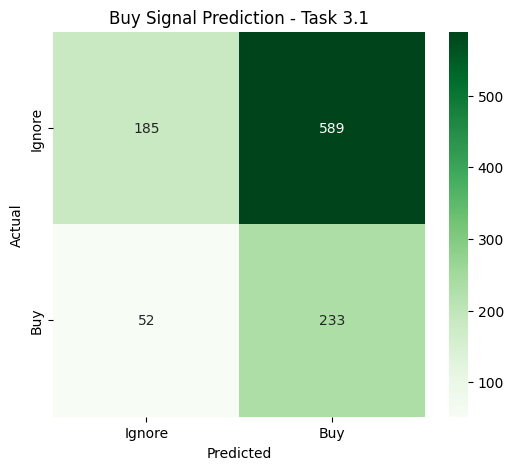


Last 5 days predictions:
Day 1: 34.90% profit probability -> Recommendation: IGNORE
Day 2: 34.70% profit probability -> Recommendation: IGNORE
Day 3: 36.90% profit probability -> Recommendation: IGNORE
Day 4: 38.56% profit probability -> Recommendation: IGNORE
Day 5: 39.76% profit probability -> Recommendation: IGNORE


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

print("Step 1: Buy Signal Labeling")

# Configure buy rules
k_days = 5
threshold = 0.02

# Calculate future return
df_price['Future_Close'] = df_price['Close'].shift(-k_days)
df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']

# Binary labeling: 1 if Return >= threshold, else 0
df_price['Buy_Signal'] = np.where(df_price['Return'] >= threshold, 1, 0)

# Drop NaNs
df_price.dropna(subset=['Buy_Signal', 'Future_Close', 'Return'], inplace=True)

print("Label distribution (0=Ignore, 1=Buy):")
print(df_price['Buy_Signal'].value_counts())

print("\nStep 2: Data Preparation")

# Define features
features_task3 = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_14', 'RSI_14', 'Log_Return', 'Volatility_14']
if 'priceToEarning' in df_price.columns: features_task3.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: features_task3.append('cashDividendPercentage')
if 'MACD' in df_price.columns: features_task3.extend(['MACD', 'Signal_Line'])

dataset_X = df_price[features_task3].values
dataset_Y = df_price['Buy_Signal'].values

# Train/Test split
train_size = int(len(dataset_X) * 0.8)
train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

# Scale data
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_raw)
test_X_scaled = scaler_X.transform(test_X_raw)

# Create sliding windows
def create_dataset_binary(X, Y, time_step=20):
    dataX, dataY = [], []
    for i in range(len(X) - time_step):
        dataX.append(X[i:(i + time_step), :])
        dataY.append(Y[i + time_step])
    return np.array(dataX), np.array(dataY)

time_step = 20
X_train, Y_train = create_dataset_binary(train_X_scaled, train_Y_raw, time_step)
X_test, Y_test = create_dataset_binary(test_X_scaled, test_Y_raw, time_step)

print("\nStep 3: Build Classification Model")

# Apply class weights
class_weight_dict = {0: 1.0, 1: 2.0}
print(f"Class weights: {class_weight_dict}")

model_buy = Sequential()
model_buy.add(LSTM(32, return_sequences=True, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.01)))
model_buy.add(BatchNormalization())
model_buy.add(Dropout(0.5))

model_buy.add(LSTM(16, kernel_regularizer=l2(0.01)))
model_buy.add(BatchNormalization())
model_buy.add(Dropout(0.5))

model_buy.add(Dense(8, activation='relu'))
model_buy.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0001)
model_buy.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model_buy.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print("\nStep 4: Evaluate and Predict Probabilities")

# Get predictions
predicted_probabilities = model_buy.predict(X_test).flatten()

# Find optimal threshold
best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.4, 0.85, 0.05):
    y_pred_temp = (predicted_probabilities > threshold).astype(int)
    f1 = f1_score(Y_test, y_pred_temp, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nOptimal threshold: {best_threshold:.2f}")

# Apply optimal threshold
Y_pred_binary = (predicted_probabilities > best_threshold).astype(int)

# Print classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_binary, target_names=['Ignore (0)', 'Buy (1)']))

# Plot confusion matrix
cm = confusion_matrix(Y_test, Y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ignore', 'Buy'], yticklabels=['Ignore', 'Buy'])
plt.title('Buy Signal Prediction - Task 3.1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Show last 5 days predictions
print("\nLast 5 days predictions:")
for i in range(1, 6):
    prob = predicted_probabilities[-i] * 100
    decision = "BUY" if prob > 50 else "IGNORE"
    print(f"Day {i}: {prob:.2f}% profit probability -> Recommendation: {decision}")

## 3.2 Sell Signal Classification


Step 5: Sell Signal Labeling (Task 3.2)
Label distribution (0 = Hold/Buy, 1 = Sell):
Sell_Signal
0    4165
1    1203
Name: count, dtype: int64

Step 6: Data Preparation

Step 7: Build Classification Model
Class weights: {0: 1.0, 1: 2.0}
Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6063 - loss: 0.9774 - val_accuracy: 0.4930 - val_loss: 0.7606
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6547 - loss: 0.8966 - val_accuracy: 0.5257 - val_loss: 0.7508
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6669 - loss: 0.8846 - val_accuracy: 0.5654 - val_loss: 0.7422
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6708 - loss: 0.8732 - val_accuracy: 0.5818 - val_loss: 0.7353
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6760 - loss: 0.8597 - val_accuracy: 0.6168 - val_loss: 0.7246
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6833 - loss: 0.8469 - val_accuracy: 0.6589 -

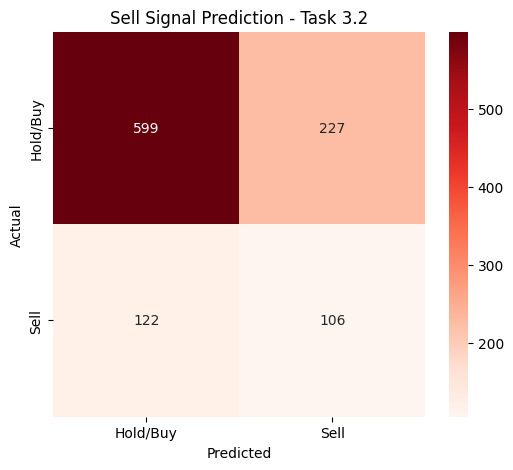

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.utils import class_weight

print("\nStep 5: Sell Signal Labeling (Task 3.2)")

# Calculate Bollinger Bands
df_price['SMA_20'] = df_price['Close'].rolling(window=20).mean()
df_price['STD_20'] = df_price['Close'].rolling(window=20).std()
df_price['Upper_Band'] = df_price['SMA_20'] + (df_price['STD_20'] * 2)
df_price['Lower_Band'] = df_price['SMA_20'] - (df_price['STD_20'] * 2)

df_price['Dist_to_UB'] = (df_price['Close'] - df_price['Upper_Band']) / df_price['Upper_Band']
df_price['BB_Percent_B'] = (df_price['Close'] - df_price['Lower_Band']) / (df_price['Upper_Band'] - df_price['Lower_Band'])

df_price.dropna(subset=['SMA_14', 'RSI_14', 'SMA_20', 'Upper_Band'], inplace=True)

# Configure sell rules
k_days = 5
threshold = -0.03

# Calculate future return
df_price['Future_Close'] = df_price['Close'].shift(-k_days)
df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']

# Sell labeling: 1 if Return <= threshold, else 0
df_price['Sell_Signal'] = np.where(df_price['Return'] <= threshold, 1, 0)
df_price.dropna(subset=['Sell_Signal', 'Future_Close', 'Return'], inplace=True)

print("Label distribution (0 = Hold/Buy, 1 = Sell):")
print(df_price['Sell_Signal'].value_counts())

print("\nStep 6: Data Preparation")

# Define features
features_task3 = ['Open', 'High', 'Low', 'Volume', 'Log_Return', 'Volatility_14', 'SMA_14', 'RSI_14', 'Close', 'Dist_to_SMA', 'Dist_to_UB', 'BB_Percent_B']
if 'priceToEarning' in df_price.columns: features_task3.append('priceToEarning')
if 'cashDividendPercentage' in df_price.columns: features_task3.append('cashDividendPercentage')

dataset_X = df_price[features_task3].values
dataset_Y = df_price['Sell_Signal'].values

# Train/Test split
train_size = int(len(dataset_X) * 0.8)
train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

# Scale data
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_raw)
test_X_scaled = scaler_X.transform(test_X_raw)

# Create sliding windows
def create_dataset_binary(X, Y, time_step=20):
    dataX, dataY = [], []
    for i in range(len(X) - time_step):
        dataX.append(X[i:(i + time_step), :])
        dataY.append(Y[i + time_step])
    return np.array(dataX), np.array(dataY)

time_step = 20
X_train, Y_train = create_dataset_binary(train_X_scaled, train_Y_raw, time_step)
X_test, Y_test = create_dataset_binary(test_X_scaled, test_Y_raw, time_step)

print("\nStep 7: Build Classification Model")

# Apply class weights
class_weight_dict = {0: 1.0, 1: 2.0}
print(f"Class weights: {class_weight_dict}")

model_sell = Sequential()
model_sell.add(LSTM(32, return_sequences=True, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.001)))
model_sell.add(BatchNormalization())
model_sell.add(Dropout(0.3))

model_sell.add(LSTM(16, kernel_regularizer=l2(0.001)))
model_sell.add(BatchNormalization())
model_sell.add(Dropout(0.3))

model_sell.add(Dense(8, activation='relu'))
model_sell.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.0001)
model_sell.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model_sell.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

print("\nStep 8: Evaluate and Find Optimal Threshold")

# Get predictions
predicted_probabilities = model_sell.predict(X_test).flatten()

best_f1 = 0
best_threshold = 0.5
best_recall = 0

# Find optimal threshold based on Precision and Recall
for threshold in np.arange(0.20, 0.8, 0.02):
    y_pred_temp = (predicted_probabilities > threshold).astype(int)

    if sum(y_pred_temp) > 0:
        f1 = f1_score(Y_test, y_pred_temp, average='binary')
        rec = recall_score(Y_test, y_pred_temp, average='binary', zero_division=0)
        prec = precision_score(Y_test, y_pred_temp, average='binary', zero_division=0)

        if f1 > best_f1 and rec >= 0.25 and prec >= 0.25:
            best_f1 = f1
            best_threshold = threshold
            best_recall = rec

if best_f1 == 0:
    best_threshold = 0.30
    print("\nNo optimal threshold found. Using default: 0.30")
else:
    print(f"\nOptimal threshold: {best_threshold:.2f} (F1: {best_f1:.3f}, Recall: {best_recall:.3f})")

# Apply optimal threshold
Y_pred_binary = (predicted_probabilities > best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_binary, target_names=['Hold/Buy (0)', 'Sell (1)']))

# Plot confusion matrix
cm = confusion_matrix(Y_test, Y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Hold/Buy', 'Sell'], yticklabels=['Hold/Buy', 'Sell'])
plt.title('Sell Signal Prediction - Task 3.2')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Portfolio Optimization & Risk Management

## 4.1 Modern Portfolio Theory (Markowitz)

In [39]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# 1. Configure paths
base_path = '/content/drive/MyDrive/data-vn-20230228'
history_path = os.path.join(base_path, 'stock-historical-data')
finance_path = os.path.join(base_path, 'financial-ratio')
dividend_path = os.path.join(base_path, 'dividend-history')

# 2. Select specific stocks
all_files = [f for f in os.listdir(history_path) if f.endswith('-History.csv')]

fixed_tickers = ['ST8', 'LCG', 'TVD', 'TC6', 'NAG', 'PLC', 'PC1', 'PVP', 'CST', 'VOC']
ticker_to_full_filename = {f.split('-')[0]: f for f in all_files}

selected_files = [ticker_to_full_filename[ticker] for ticker in fixed_tickers if ticker in ticker_to_full_filename]

if len(selected_files) != len(fixed_tickers):
    missing_tickers = [ticker for ticker in fixed_tickers if ticker not in ticker_to_full_filename]
    print(f"Warning: Missing history files for: {missing_tickers}")

tickers = [f.split('-')[0] for f in selected_files]
print(f"Selected stocks ({len(tickers)}): {tickers}\n")

# Process and evaluate stock
def process_and_evaluate_stock(target_history_file):
    base_name = target_history_file.replace('-History.csv', '')
    ticker = base_name.split('-')[0]
    print(f"--- Processing: {ticker} ---")

    # Process price data
    df_price = pd.read_csv(os.path.join(history_path, target_history_file))
    if len(df_price) < 120:
        return None

    df_price['TradingDate'] = pd.to_datetime(df_price['TradingDate'])
    df_price = df_price.sort_values('TradingDate').reset_index(drop=True)

    df_price['Log_Return'] = np.log(df_price['Close'] / df_price['Close'].shift(1))
    df_price['Volatility_14'] = df_price['Log_Return'].rolling(window=14).std()
    df_price['SMA_14'] = df_price['Close'].rolling(window=14).mean()
    df_price['Dist_to_SMA'] = (df_price['Close'] - df_price['SMA_14']) / df_price['SMA_14']

    delta = df_price['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_price['RSI_14'] = 100 - (100 / (1 + rs))

    # Merge finance data
    finance_file = f"{base_name}-Finance.csv"
    if os.path.exists(os.path.join(finance_path, finance_file)):
        df_fin = pd.read_csv(os.path.join(finance_path, finance_file))
        def get_quarter_end(row):
            try:
                q, y = int(row['quarter']), int(row['year'])
                return pd.Timestamp(y, 3 * q, 30) if q in [2,3] else pd.Timestamp(y, 3, 31) if q==1 else pd.Timestamp(y, 12, 31)
            except: return pd.NaT
        if 'quarter' in df_fin.columns and 'year' in df_fin.columns:
            df_fin['ReportDate'] = df_fin.apply(get_quarter_end, axis=1)
            cols_to_keep = [c for c in ['ReportDate', 'priceToEarning', 'roe', 'roa'] if c in df_fin.columns]
            df_fin = df_fin[cols_to_keep]
            df_price = pd.merge(df_price, df_fin, left_on='TradingDate', right_on='ReportDate', how='left')
            for col in cols_to_keep:
                if col != 'ReportDate': df_price[col] = df_price[col].fillna(method='ffill')
            df_price.drop(columns=['ReportDate'], inplace=True, errors='ignore')

    # Merge dividend data
    dividend_file = f"{base_name}-Dividend.csv"
    if os.path.exists(os.path.join(dividend_path, dividend_file)):
        df_div = pd.read_csv(os.path.join(dividend_path, dividend_file))
        if 'exerciseDate' in df_div.columns and 'cashDividendPercentage' in df_div.columns:
            df_div['exerciseDate'] = pd.to_datetime(df_div['exerciseDate'], format='%d/%m/%y', errors='coerce')
            df_div_agg = df_div.groupby('exerciseDate')['cashDividendPercentage'].sum().reset_index()
            df_price = pd.merge(df_price, df_div_agg, left_on='TradingDate', right_on='exerciseDate', how='left')
            df_price['cashDividendPercentage'] = df_price['cashDividendPercentage'].fillna(0)
            df_price.drop(columns=['exerciseDate'], inplace=True, errors='ignore')

    df_price.dropna(subset=['SMA_14', 'RSI_14'], inplace=True)
    df_price.fillna(method='bfill', inplace=True)

    # Labeling (Buy if Return >= 2% in 5 days)
    k_days = 5
    threshold = 0.02
    df_price['Future_Close'] = df_price['Close'].shift(-k_days)
    df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']
    df_price['Buy_Signal'] = np.where(df_price['Return'] >= threshold, 1, 0)
    df_price.dropna(subset=['Buy_Signal', 'Future_Close', 'Return'], inplace=True)

    # Annualized historical return
    historical_mean_return = df_price['Log_Return'].mean() * 252

    # Prepare features
    features_task3 = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_14', 'RSI_14', 'Log_Return', 'Volatility_14', 'Dist_to_SMA']
    if 'priceToEarning' in df_price.columns: features_task3.append('priceToEarning')
    if 'cashDividendPercentage' in df_price.columns: features_task3.append('cashDividendPercentage')

    dataset_X, dataset_Y = df_price[features_task3].values, df_price['Buy_Signal'].values
    train_size = int(len(dataset_X) * 0.8)
    train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
    train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_X_raw)
    test_X_scaled = scaler_X.transform(test_X_raw)

    def create_dataset(X, Y, time_step=20):
        return np.array([X[i:(i + time_step), :] for i in range(len(X) - time_step)]), np.array([Y[i + time_step] for i in range(len(X) - time_step)])

    time_step = 20
    X_train, Y_train = create_dataset(train_X_scaled, train_Y_raw, time_step)
    X_test, Y_test = create_dataset(test_X_scaled, test_Y_raw, time_step)

    # Train model
    model = Sequential()
    model.add(LSTM(32, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

    print("Training model...")
    model.fit(X_train, Y_train, epochs=30, batch_size=32, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5)], verbose=0, class_weight={0: 1.0, 1: 2.0})

    # Evaluate last 20 days
    preds = model.predict(X_test, verbose=0).flatten()
    last_month_probs = preds[-20:]
    mean_buy_prob = np.mean(last_month_probs)

    print(f"Completed | 20-day avg buy probability: {mean_buy_prob:.2%}\n")

    return {
        'Ticker': ticker,
        'Mean_Buy_Probability': mean_buy_prob,
        'Annualized_Historical_Return': historical_mean_return
    }

# 3. Iterate through selected stocks
portfolio_results = []
for file in selected_files:
    res = process_and_evaluate_stock(file)
    if res:
        portfolio_results.append(res)

# 4. Aggregate results
df_portfolio = pd.DataFrame(portfolio_results)
df_portfolio = df_portfolio.sort_values('Mean_Buy_Probability', ascending=False).reset_index(drop=True)

print("Portfolio Evaluation Results")
print(df_portfolio.to_string())
print("\nPriority: Highest Mean_Buy_Probability gets maximum capital allocation.")

Selected stocks (10): ['ST8', 'LCG', 'TVD', 'TC6', 'NAG', 'PLC', 'PC1', 'PVP', 'CST', 'VOC']

--- Processing: ST8 ---
Training model...
Completed | 20-day avg buy probability: 24.72%

--- Processing: LCG ---
Training model...
Completed | 20-day avg buy probability: 39.46%

--- Processing: TVD ---
Training model...
Completed | 20-day avg buy probability: 32.27%

--- Processing: TC6 ---
Training model...
Completed | 20-day avg buy probability: 14.50%

--- Processing: NAG ---
Training model...
Completed | 20-day avg buy probability: 31.24%

--- Processing: PLC ---
Training model...
Completed | 20-day avg buy probability: 51.47%

--- Processing: PC1 ---
Training model...
Completed | 20-day avg buy probability: 50.18%

--- Processing: PVP ---
Training model...
Completed | 20-day avg buy probability: 62.62%

--- Processing: CST ---
Training model...
Completed | 20-day avg buy probability: 56.03%

--- Processing: VOC ---
Training model...
Completed | 20-day avg buy probability: 29.23%

Portfo

In [40]:
!pip install PyPortfolioOpt

In [42]:
import pandas as pd
import numpy as np
import os
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.efficient_frontier import EfficientFrontier

print("Step 1: Build Historical Price Matrix")

combined_prices = pd.DataFrame()

for file in selected_files:
    ticker = file.replace('-History.csv', '').split('-')[0]
    df_temp = pd.read_csv(os.path.join(history_path, file))
    df_temp['TradingDate'] = pd.to_datetime(df_temp['TradingDate'])
    df_temp = df_temp.set_index('TradingDate')

    combined_prices[ticker] = df_temp['Close']

combined_prices = combined_prices.dropna()

print("Historical price data combined.")

print("\nStep 2: Load LSTM Expected Returns")

# Configure strategy parameters
target_profit = 0.10
stop_loss = 0.05

# Calculate expected return based on LSTM probability
ai_expected_returns = {}
for index, row in df_portfolio.iterrows():
    ticker = row['Ticker']
    p_buy = row['Mean_Buy_Probability']
    p_loss = 1 - p_buy

    exp_return = (p_buy * target_profit) - (p_loss * stop_loss)
    ai_expected_returns[ticker] = exp_return

mu = pd.Series(ai_expected_returns)
print("LSTM expected returns:")
print(mu.apply(lambda x: f"{x:.2%}"))

print("\nStep 3: Markowitz Optimization")

# Calculate Covariance Matrix (Historical Risk)
S = risk_models.CovarianceShrinkage(combined_prices).ledoit_wolf()

# Initialize Efficient Frontier (Long-only)
ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))

try:
    # Maximize Sharpe ratio assuming 4.5% risk-free rate
    weights = ef.max_sharpe(risk_free_rate=0.045)
    cleaned_weights = ef.clean_weights()

    print("\nOptimal Portfolio Weights:")
    for ticker, weight in cleaned_weights.items():
        print(f"{ticker}: {weight:.1%}")

    print("\nTheoretical Portfolio Performance:")
    ef.portfolio_performance(verbose=True, risk_free_rate=0.045)

except Exception as e:
    print(f"\nOptimization failed: {e}")
    print("Reason: No expected returns exceed the risk-free rate (4.5%). Recommendation: Stay in cash.")

Step 1: Build Historical Price Matrix
Historical price data combined.

Step 2: Load LSTM Expected Returns
LSTM expected returns:
PVP     4.39%
CST     3.40%
PLC     2.72%
PC1     2.53%
LCG     0.92%
TVD    -0.16%
NAG    -0.31%
VOC    -0.62%
ST8    -1.29%
TC6    -2.83%
dtype: object

Step 3: Markowitz Optimization

Optimization failed: at least one of the assets must have an expected return exceeding the risk-free rate
Reason: No expected returns exceed the risk-free rate (4.5%). Recommendation: Stay in cash.


## 4.2 Risk Scoring & Asset Filtering

In [43]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Configure paths
base_path = '/content/drive/MyDrive/data-vn-20230228'
history_path = os.path.join(base_path, 'stock-historical-data')

# Define target stocks
target_tickers = ['ST8', 'LCG', 'TVD', 'TC6', 'NAG', 'PLC', 'PC1', 'PVP', 'CST', 'VOC']
print(f"Extracting risk data for {len(target_tickers)} stocks: {target_tickers}\n")

risk_results = []

def extract_risk_features(ticker):
    print(f"--- Analyzing sell risk for: {ticker} ---")

    # Find matching file
    actual_file = [f for f in os.listdir(history_path) if f.startswith(ticker + '-')]
    if not actual_file:
        print(f"File not found for {ticker}")
        return None

    file_path = os.path.join(history_path, actual_file[0])
    df_price = pd.read_csv(file_path)

    df_price['TradingDate'] = pd.to_datetime(df_price['TradingDate'])
    df_price = df_price.sort_values('TradingDate').reset_index(drop=True)

    # Feature engineering
    df_price['Log_Return'] = np.log(df_price['Close'] / df_price['Close'].shift(1))
    df_price['Volatility_14'] = df_price['Log_Return'].rolling(window=14).std()

    df_price['SMA_14'] = df_price['Close'].rolling(window=14).mean()
    df_price['Dist_to_SMA'] = (df_price['Close'] - df_price['SMA_14']) / df_price['SMA_14']

    delta = df_price['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_price['RSI_14'] = 100 - (100 / (1 + rs))

    # Bollinger Bands
    df_price['SMA_20'] = df_price['Close'].rolling(window=20).mean()
    df_price['STD_20'] = df_price['Close'].rolling(window=20).std()
    df_price['Upper_Band'] = df_price['SMA_20'] + (df_price['STD_20'] * 2)
    df_price['Lower_Band'] = df_price['SMA_20'] - (df_price['STD_20'] * 2)

    df_price['Dist_to_UB'] = (df_price['Close'] - df_price['Upper_Band']) / df_price['Upper_Band']
    df_price['BB_Percent_B'] = (df_price['Close'] - df_price['Lower_Band']) / (df_price['Upper_Band'] - df_price['Lower_Band'])

    # Baseline risk metrics (last 20 days)
    mean_volatility = df_price['Volatility_14'].tail(20).mean()
    mean_dist_ub = df_price['Dist_to_UB'].tail(20).mean()

    # Clean and label data
    df_price.dropna(subset=['SMA_14', 'RSI_14', 'SMA_20', 'Upper_Band'], inplace=True)

    k_days = 5
    threshold = -0.03
    df_price['Future_Close'] = df_price['Close'].shift(-k_days)
    df_price['Return'] = (df_price['Future_Close'] - df_price['Close']) / df_price['Close']
    df_price['Sell_Signal'] = np.where(df_price['Return'] <= threshold, 1, 0)
    df_price.dropna(subset=['Sell_Signal', 'Future_Close', 'Return'], inplace=True)

    # Prepare training data
    features_task3 = ['Open', 'High', 'Low', 'Volume', 'Log_Return', 'Volatility_14', 'SMA_14', 'RSI_14', 'Dist_to_SMA', 'Dist_to_UB', 'BB_Percent_B']

    dataset_X = df_price[features_task3].values
    dataset_Y = df_price['Sell_Signal'].values

    train_size = int(len(dataset_X) * 0.8)
    train_X_raw, test_X_raw = dataset_X[:train_size], dataset_X[train_size:]
    train_Y_raw, test_Y_raw = dataset_Y[:train_size], dataset_Y[train_size:]

    scaler_X = StandardScaler()
    train_X_scaled = scaler_X.fit_transform(train_X_raw)
    test_X_scaled = scaler_X.transform(test_X_raw)

    def create_dataset_binary(X, Y, time_step=20):
        dataX, dataY = [], []
        for i in range(len(X) - time_step):
            dataX.append(X[i:(i + time_step), :])
            dataY.append(Y[i + time_step])
        return np.array(dataX), np.array(dataY)

    time_step = 20
    X_train, Y_train = create_dataset_binary(train_X_scaled, train_Y_raw, time_step)
    X_test, Y_test = create_dataset_binary(test_X_scaled, test_Y_raw, time_step)

    # Build and train model
    model_sell = Sequential()
    model_sell.add(LSTM(32, return_sequences=True, input_shape=(time_step, len(features_task3)), kernel_regularizer=l2(0.001)))
    model_sell.add(Dropout(0.3))
    model_sell.add(LSTM(16, kernel_regularizer=l2(0.001)))
    model_sell.add(Dropout(0.3))
    model_sell.add(Dense(8, activation='relu'))
    model_sell.add(Dense(1, activation='sigmoid'))

    model_sell.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    print(f"Training risk model for {ticker}...")
    model_sell.fit(X_train, Y_train, epochs=30, batch_size=32, validation_split=0.1,
                   callbacks=[early_stop], class_weight={0: 1.0, 1: 2.0}, verbose=0)

    # Get last 20 days sell probability
    predicted_probabilities = model_sell.predict(X_test, verbose=0).flatten()
    sell_prob = np.mean(predicted_probabilities[-20:])

    print(f"Completed | Sell prob: {sell_prob:.1%} | Volatility: {mean_volatility:.3f} | Dist_UB: {mean_dist_ub:.3f}\n")

    return {
        'Ticker': ticker,
        'Sell_Probability': sell_prob,
        'Mean_Volatility': mean_volatility,
        'Dist_to_UB': mean_dist_ub
    }

# Iterate through target tickers
for ticker in target_tickers:
    res = extract_risk_features(ticker)
    if res:
        risk_results.append(res)

# Create risk DataFrame
df_risk = pd.DataFrame(risk_results)

print("Risk data preparation completed.")
print(df_risk.to_string())

Extracting risk data for 10 stocks: ['ST8', 'LCG', 'TVD', 'TC6', 'NAG', 'PLC', 'PC1', 'PVP', 'CST', 'VOC']

--- Analyzing sell risk for: ST8 ---
Training risk model for ST8...
Completed | Sell prob: 31.7% | Volatility: 0.049 | Dist_UB: -0.058

--- Analyzing sell risk for: LCG ---
Training risk model for LCG...
Completed | Sell prob: 57.5% | Volatility: 0.042 | Dist_UB: -0.054

--- Analyzing sell risk for: TVD ---
Training risk model for TVD...
Completed | Sell prob: 30.4% | Volatility: 0.053 | Dist_UB: -0.081

--- Analyzing sell risk for: TC6 ---
Training risk model for TC6...
Completed | Sell prob: 69.9% | Volatility: 0.060 | Dist_UB: -0.088

--- Analyzing sell risk for: NAG ---
Training risk model for NAG...
Completed | Sell prob: 80.9% | Volatility: 0.024 | Dist_UB: -0.076

--- Analyzing sell risk for: PLC ---
Training risk model for PLC...
Completed | Sell prob: 37.9% | Volatility: 0.039 | Dist_UB: -0.061

--- Analyzing sell risk for: PC1 ---
Training risk model for PC1...
Complete

In [44]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("\nStep 2: Calculate Composite Risk Score")

# Normalize Volatility and Dist_to_UB to [0, 1]
scaler = MinMaxScaler()
df_risk[['Vol_Score', 'Tech_Risk_Score']] = scaler.fit_transform(df_risk[['Mean_Volatility', 'Dist_to_UB']])

# Apply weighted risk formula (50% AI, 30% Volatility, 20% Technical)
w_ai = 0.50
w_vol = 0.30
w_tech = 0.20

df_risk['Total_Risk_Score'] = (
    (df_risk['Sell_Probability'] * w_ai) +
    (df_risk['Vol_Score'] * w_vol) +
    (df_risk['Tech_Risk_Score'] * w_tech)
)

# Categorize risk (Threshold > 0.50)
df_risk['Status'] = np.where(df_risk['Total_Risk_Score'] > 0.50, 'EXCLUDED', 'KEPT')

# Sort results
df_risk = df_risk.sort_values('Total_Risk_Score', ascending=False).reset_index(drop=True)

print("Risk Ranking:")
formatters = {
    'Sell_Probability': '{:.1%}'.format,
    'Total_Risk_Score': '{:.1%}'.format
}
print(df_risk[['Ticker', 'Sell_Probability', 'Total_Risk_Score', 'Status']].to_string(formatters=formatters))

print("\nStep 3: Final Portfolio Selection")
safe_portfolio = df_risk[df_risk['Status'] == 'KEPT']['Ticker'].tolist()
excluded_portfolio = df_risk[df_risk['Status'] == 'EXCLUDED']['Ticker'].tolist()

print(f"Excluded stocks: {excluded_portfolio}")
print(f"Safe stocks kept: {safe_portfolio}")


Step 2: Calculate Composite Risk Score
Risk Ranking:
  Ticker Sell_Probability Total_Risk_Score    Status
0    TC6            69.9%            76.5%  EXCLUDED
1    LCG            57.5%            65.5%  EXCLUDED
2    CST            51.3%            59.0%  EXCLUDED
3    NAG            80.9%            58.7%  EXCLUDED
4    ST8            31.7%            56.6%  EXCLUDED
5    TVD            30.4%            53.2%  EXCLUDED
6    PLC            37.9%            51.9%  EXCLUDED
7    PC1            40.1%            50.0%      KEPT
8    VOC            37.5%            32.8%      KEPT
9    PVP            35.9%            24.1%      KEPT

Step 3: Final Portfolio Selection
Excluded stocks: ['TC6', 'LCG', 'CST', 'NAG', 'ST8', 'TVD', 'PLC']
Safe stocks kept: ['PC1', 'VOC', 'PVP']


## 4.3 Strategic Asset Allocation

In [45]:
import pandas as pd
import numpy as np
from pypfopt import risk_models, expected_returns
from pypfopt.efficient_frontier import EfficientFrontier

print("Task 4.3: Consolidated Portfolio Allocation")

# 1. Merge profit (Task 4.1) and risk (Task 4.2) data
df_final = pd.merge(df_portfolio, df_risk, on='Ticker')

print("\nConsolidated Profit and Risk Table")
print(df_final[['Ticker', 'Mean_Buy_Probability', 'Total_Risk_Score', 'Status']].to_string())

# 2. Apply allocation strategy (Keep 'KEPT' status only)
# Note: Matching the English status labels established in previous steps
valid_candidates = df_final[df_final['Status'] == 'KEPT']
valid_tickers = valid_candidates['Ticker'].tolist()

print(f"\nTickers passing the risk filter: {valid_tickers}")

# 3. Allocation scenarios
if len(valid_tickers) == 0:
    print("\nWarning: All tickers exceed 50% risk threshold.")
    print("Optimal Strategy: Stay out of the market. Allocate 100% to Cash or Bonds.")

elif len(valid_tickers) == 1:
    sole_ticker = valid_tickers[0]
    print(f"\nConcentration risk detected: Only 1 safe ticker ({sole_ticker}).")
    print(f"Optimal Strategy: Allocate max 30% to {sole_ticker}, 70% to Cash.")

else:
    print("\nDiversification conditions met. Running Markowitz optimization...")

    # Filter historical price matrix
    safe_prices = combined_prices[valid_tickers]

    # Calculate expected returns (Target 10%, Stoploss 5%)
    target_profit = 0.10
    stop_loss = 0.05
    safe_returns = {}

    for index, row in valid_candidates.iterrows():
        p_buy = row['Mean_Buy_Probability']
        exp_return = (p_buy * target_profit) - ((1 - p_buy) * stop_loss)
        safe_returns[row['Ticker']] = exp_return

    mu_safe = pd.Series(safe_returns)

    # Calculate Covariance Matrix
    S_safe = risk_models.CovarianceShrinkage(safe_prices).ledoit_wolf()

    # Initialize Efficient Frontier
    ef = EfficientFrontier(mu_safe, S_safe, weight_bounds=(0.0, 1.0))

    try:
        # Maximize Sharpe Ratio (Assuming 4.5% risk-free rate)
        weights = ef.max_sharpe(risk_free_rate=0.045)
        cleaned_weights = ef.clean_weights()

        print("\nFinal Capital Allocation Weights")
        for ticker, weight in cleaned_weights.items():
            if weight > 0:
                print(f"{ticker}: {weight:.1%}")

        print("\nPortfolio Performance Evaluation")
        ef.portfolio_performance(verbose=True, risk_free_rate=0.045)

    except Exception as e:
        print("\nOptimization Error: Expected returns are lower than the risk-free rate (4.5%).")
        print("Strategy: Hold 100% Cash.")

Task 4.3: Consolidated Portfolio Allocation

Consolidated Profit and Risk Table
  Ticker  Mean_Buy_Probability  Total_Risk_Score    Status
0    PVP              0.626200          0.240853      KEPT
1    CST              0.560314          0.590150  EXCLUDED
2    PLC              0.514655          0.519269  EXCLUDED
3    PC1              0.501795          0.499603      KEPT
4    LCG              0.394625          0.655479  EXCLUDED
5    TVD              0.322679          0.531713  EXCLUDED
6    NAG              0.312399          0.586613  EXCLUDED
7    VOC              0.292268          0.327660      KEPT
8    ST8              0.247220          0.565613  EXCLUDED
9    TC6              0.144963          0.764792  EXCLUDED

Tickers passing the risk filter: ['PVP', 'PC1', 'VOC']

Diversification conditions met. Running Markowitz optimization...

Optimization Error: Expected returns are lower than the risk-free rate (4.5%).
Strategy: Hold 100% Cash.


In [46]:
# Strategy recommendation by risk appetite
print("\nSTRATEGY RECOMMENDATION BY RISK APPETITE")

# Prudent strategy: low risk and high buy probability
prudent_threshold = 0.35
# Aggressive strategy: accept risk up to 60%
aggressive_threshold = 0.60

prudent_stocks = df_final[
    (df_final['Total_Risk_Score'] < prudent_threshold) &
    (df_final['Mean_Buy_Probability'] > 0.45)
]['Ticker'].tolist()

# Aggressive strategy: higher risk tolerance
aggressive_stocks = df_final[
    df_final['Total_Risk_Score'] < aggressive_threshold
]['Ticker'].tolist()

print(f"Prudent Portfolio (Risk < 35%): {prudent_stocks}")
print(f"Aggressive Portfolio (Risk < 60%): {aggressive_stocks}")

print("\nExplanation: Prudent investors prioritize capital preservation,")
print("selecting stocks with low risk scores and good buy probability.")
print("Aggressive investors accept higher volatility for potential")
print("higher returns from strong momentum stocks.")


STRATEGY RECOMMENDATION BY RISK APPETITE
Prudent Portfolio (Risk < 35%): ['PVP']
Aggressive Portfolio (Risk < 60%): ['PVP', 'CST', 'PLC', 'PC1', 'TVD', 'NAG', 'VOC', 'ST8']

Explanation: Prudent investors prioritize capital preservation,
selecting stocks with low risk scores and good buy probability.
Aggressive investors accept higher volatility for potential
higher returns from strong momentum stocks.
